<a href="https://colab.research.google.com/github/gautamkushwaha/50-days-of-coding/blob/main/m25csa037.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Implement a fully connected neural network (MLP) using PyTorch to classify the MNIST handwritten digit dataset. Preprocess the data by flattening each image into a 1D vector and normalizing it. Experiment with different numbers of hidden layers, neurons per layer, activation functions, optimizers, and learning rates to obtain the best classification performance. Use a proper train–validation–test split. Report accuracy, precision, recall, and F1-score on the test set, and plot training vs validation loss curves to analyze model behavior and overfitting.
Use PyTorch only
- Use fully connected layers only (no CNNs)
- Plot training vs validation loss for your experiments
- Report accuracy, precision, recall, and F1-score
- Clearly mention the best-performing model configuration
- Submit the <Roll No.>.ipynb file (do not add colab link) with proper visualization and outputs

In [1]:
# Install required libraries
!pip install torch torchvision
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install numpy

In [2]:
# Import the required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
print("1. LOADING MNIST DATASET")


# Define transformations: flatten 28x28 image to 784 and normalize
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor (0 to 1)
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean & std
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 1D
])

# Load dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Split training data into train (80%) and validation (20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_dataset)}")

1. LOADING MNIST DATASET
Training samples: 48000
Validation samples: 12000
Test samples: 10000



Showing sample images...


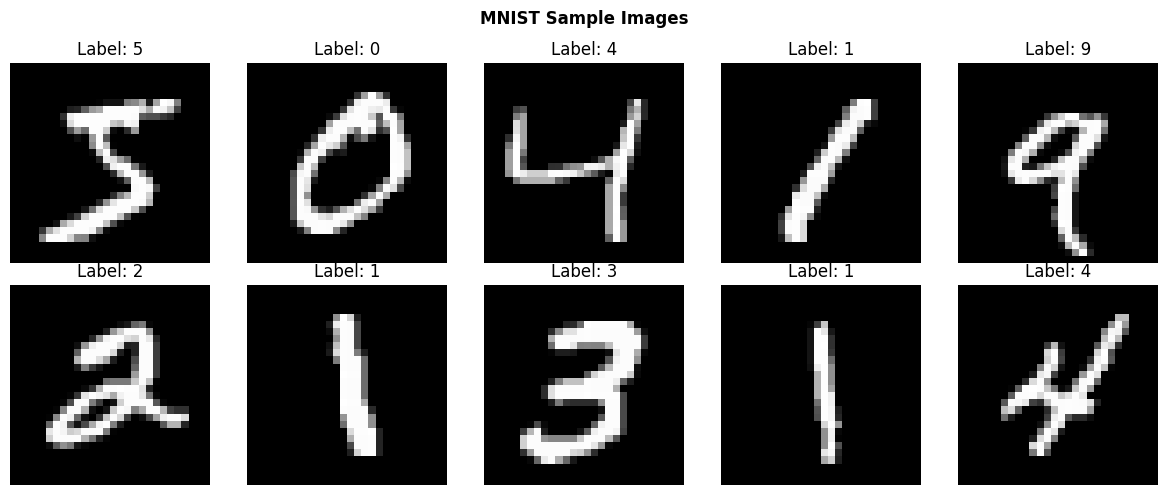

In [5]:
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# Show some sample images
print("\nShowing sample images...")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = train_dataset[i]
    img_reshaped = img.view(28, 28).numpy()
    ax = axes[i//5, i%5]
    ax.imshow(img_reshaped, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.suptitle("MNIST Sample Images", fontweight='bold')
plt.tight_layout()
plt.show()



In [6]:
print("2. CREATING NEURAL NETWORK (MLP)")

class SimpleMLP(nn.Module):
    def __init__(self, input_size=784, hidden_layers=[128, 64], num_classes=10, activation='relu'):
        super(SimpleMLP, self).__init__()

        # Create layers
        layers = []
        prev_size = input_size

        # Add hidden layers
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))

            # Add activation
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            else:
                layers.append(nn.ReLU())

            # Add dropout to prevent overfitting
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, num_classes))

        # Combine all layers
        self.model = nn.Sequential(*layers)

        print(f"Model created with:")
        print(f"  Input: {input_size}")
        for i, size in enumerate(hidden_layers):
            print(f"  Hidden layer {i+1}: {size} neurons")
        print(f"  Output: {num_classes}")
        print(f"  Activation: {activation}")

    def forward(self, x):
        return self.model(x)


2. CREATING NEURAL NETWORK (MLP)


In [7]:
test_model = SimpleMLP()
print(f"\nTotal parameters: {sum(p.numel() for p in test_model.parameters()):,}")

Model created with:
  Input: 784
  Hidden layer 1: 128 neurons
  Hidden layer 2: 64 neurons
  Output: 10
  Activation: relu

Total parameters: 109,386


In [8]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        # Forward pass
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


In [9]:
def validate(model, val_loader, criterion):
    """Validate the model"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()

    return total_loss / len(val_loader)


In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    """Main training function"""
    train_losses = []
    val_losses = []

    print("\nTraining started...")
    for epoch in range(epochs):
        # Train
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        train_losses.append(train_loss)

        # Validate
        val_loss = validate(model, val_loader, criterion)
        val_losses.append(val_loss)

        # Print progress every 5 epochs
        if (epoch + 1) % 1 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

In [13]:
def test_model(model, test_loader):
    """Test the model and calculate metrics"""
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_predictions)
    precision = precision_score(all_targets, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_predictions, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_predictions, average='weighted', zero_division=0)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_predictions,
        'targets': all_targets
    }

In [14]:

print("EXPERIMENT 1: TESTING DIFFERENT NETWORK SIZES")


# Define different architectures to test
network_configs = {
    'Small': [64],          # Small network
    'Medium': [128, 64],    # Medium network
}

results_experiment1 = {}

for name, hidden_layers in network_configs.items():
    print(f"\n--- Testing {name} Network ({hidden_layers}) ---")

    # Create model
    model = SimpleMLP(hidden_layers=hidden_layers, activation='relu').to(device)

    # Define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train model
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=5
    )

    # Test model
    test_results = test_model(model, test_loader)

    # Store results
    results_experiment1[name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_results': test_results
    }

    print(f"Test Accuracy: {test_results['accuracy']:.4f}")

EXPERIMENT 1: TESTING DIFFERENT NETWORK SIZES

--- Testing Small Network ([64]) ---
Model created with:
  Input: 784
  Hidden layer 1: 64 neurons
  Output: 10
  Activation: relu

Training started...
Epoch   1/5 | Train Loss: 0.4277 | Val Loss: 0.2304
Epoch   2/5 | Train Loss: 0.2538 | Val Loss: 0.1789
Epoch   3/5 | Train Loss: 0.2121 | Val Loss: 0.1529
Epoch   4/5 | Train Loss: 0.1889 | Val Loss: 0.1459
Epoch   5/5 | Train Loss: 0.1770 | Val Loss: 0.1363
Test Accuracy: 0.9647

--- Testing Medium Network ([128, 64]) ---
Model created with:
  Input: 784
  Hidden layer 1: 128 neurons
  Hidden layer 2: 64 neurons
  Output: 10
  Activation: relu

Training started...
Epoch   1/5 | Train Loss: 0.4412 | Val Loss: 0.1827
Epoch   2/5 | Train Loss: 0.2227 | Val Loss: 0.1445
Epoch   3/5 | Train Loss: 0.1794 | Val Loss: 0.1272
Epoch   4/5 | Train Loss: 0.1574 | Val Loss: 0.1091
Epoch   5/5 | Train Loss: 0.1414 | Val Loss: 0.1101
Test Accuracy: 0.9717



Plotting training curves for Experiment 1...


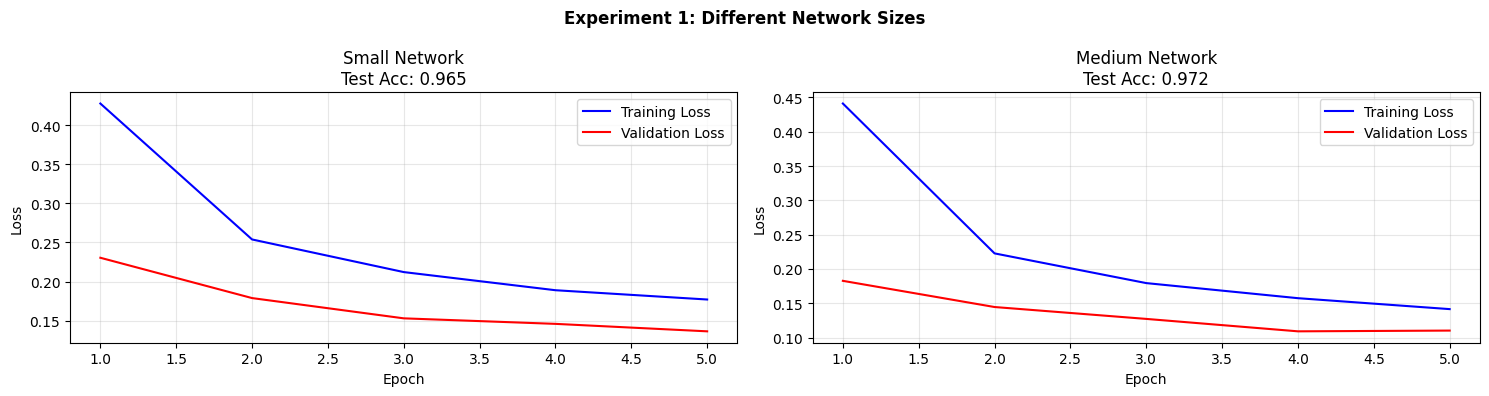

In [16]:
# Plot results
print("\nPlotting training curves for Experiment 1...")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for idx, (name, results) in enumerate(results_experiment1.items()):
    ax = axes[idx]
    epochs = range(1, len(results['train_losses']) + 1)

    ax.plot(epochs, results['train_losses'], 'b-', label='Training Loss')
    ax.plot(epochs, results['val_losses'], 'r-', label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{name} Network\nTest Acc: {results["test_results"]["accuracy"]:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Experiment 1: Different Network Sizes", fontweight='bold')
plt.tight_layout()
plt.show()

PLOTTING TRAINING VS VALIDATION LOSS


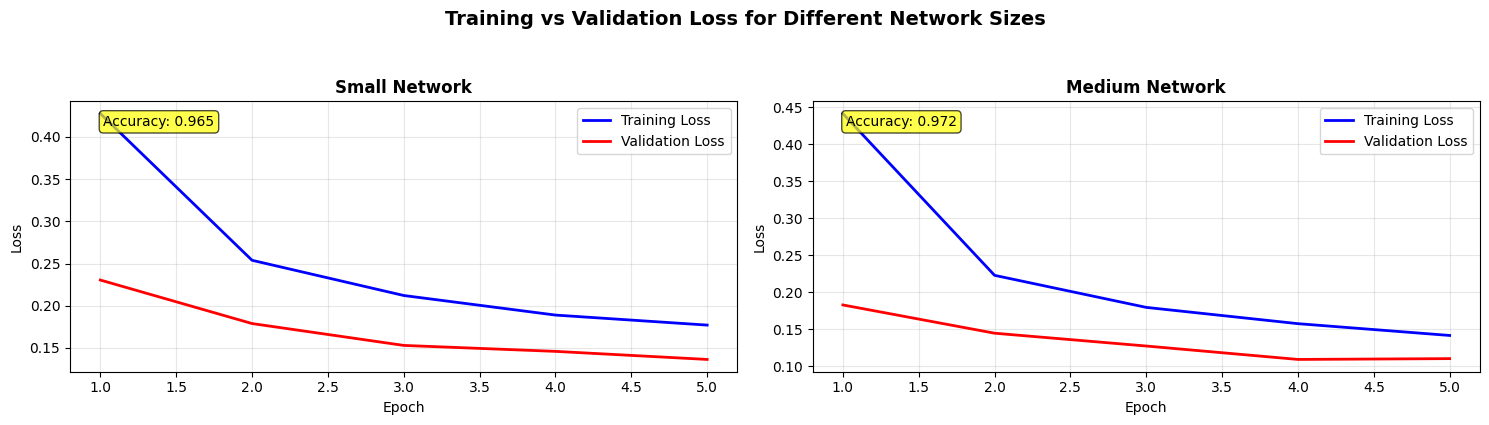

In [19]:
print("PLOTTING TRAINING VS VALIDATION LOSS")
print("="*60)

# Create a figure with subplots (one for each network)
fig, axes = plt.subplots(1, len(results_experiment1), figsize=(15, 4))

# Handle the case of a single subplot gracefully
if len(results_experiment1) == 1:
    axes = [axes] # Make axes iterable if there's only one subplot

# Colors for different networks (optional, but good for consistency)
colors = ['blue', 'green', 'red']

for idx, (name, network_results) in enumerate(results_experiment1.items()):
    ax = axes[idx]

    # Get losses
    train_loss = network_results['train_losses']
    val_loss = network_results['val_losses']
    epochs = range(1, len(train_loss) + 1)

    # Plot training loss (blue line)
    ax.plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss')

    # Plot validation loss (red line)
    ax.plot(epochs, val_loss, 'r-', linewidth=2, label='Validation Loss')

    # Customize the plot
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{name} Network', fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add accuracy on the plot
    accuracy = network_results['test_results']['accuracy']
    ax.text(0.05, 0.95, f'Accuracy: {accuracy:.3f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Add a main title
plt.suptitle('Training vs Validation Loss for Different Network Sizes',
             fontweight='bold', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [21]:
print("\n" + "="*60)
print("COMPARING ALL NETWORKS")
print("="*60)

print(f"\n{'Network':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 55)

# Corrected to use results_experiment1
for name, network_results in results_experiment1.items():
    test_metrics = network_results['test_results']
    print(f"{name:<10} {test_metrics['accuracy']:<10.4f} "
          f"{test_metrics['precision']:<10.4f} "
          f"{test_metrics['recall']:<10.4f} "
          f"{test_metrics['f1']:<10.4f}")

# Find the best network
# Corrected to use results_experiment1
best_network_name, best_network_data = max(results_experiment1.items(), key=lambda x: x[1]['test_results']['accuracy'])
print(f"\n🏆 Best Network: {best_network_name}")
print(f"   Best Accuracy: {best_network_data['test_results']['accuracy']:.4f}")


COMPARING ALL NETWORKS

Network    Accuracy   Precision  Recall     F1-Score  
-------------------------------------------------------
Small      0.9647     0.9647     0.9647     0.9647    
Medium     0.9717     0.9718     0.9717     0.9717    

🏆 Best Network: Medium
   Best Accuracy: 0.9717



OVERFITTING ANALYSIS


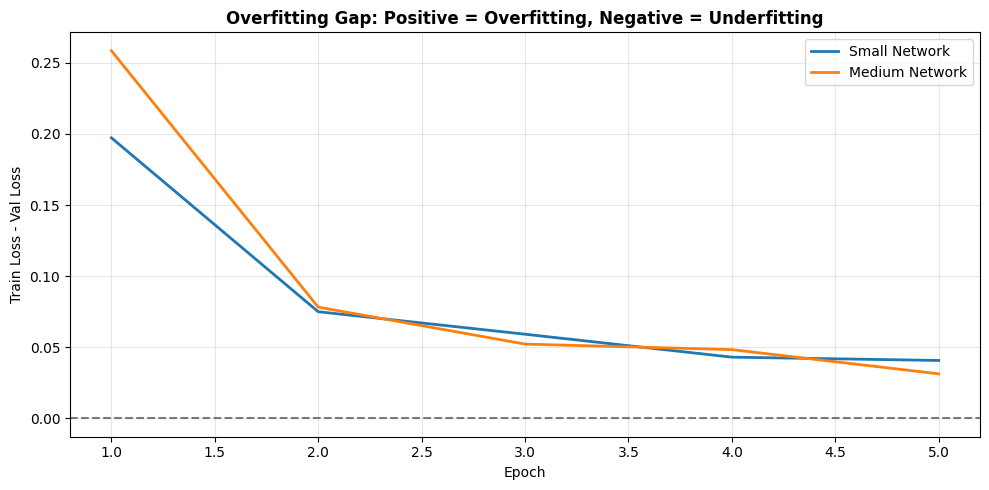


📊 What the graphs show:
1. Training Loss (Blue line): How well the model learns from training data
2. Validation Loss (Red line): How well the model generalizes to new data
3. Overfitting happens when:
   - Training loss keeps decreasing
   - But validation loss starts increasing
4. Good model: Both losses decrease together


In [23]:
print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

plt.figure(figsize=(10, 5))

# Plot the gap between training and validation loss
for name, network_results in results_experiment1.items(): # Corrected to use results_experiment1
    train_loss = network_results['train_losses']
    val_loss = network_results['val_losses']
    epochs = range(1, len(train_loss) + 1)

    # Calculate difference (gap)
    loss_gap = [train_loss[i] - val_loss[i] for i in range(len(train_loss))]

    plt.plot(epochs, loss_gap, label=f'{name} Network', linewidth=2)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('Train Loss - Val Loss')
plt.title('Overfitting Gap: Positive = Overfitting, Negative = Underfitting',
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Explanation
print("\n📊 What the graphs show:")
print("1. Training Loss (Blue line): How well the model learns from training data")
print("2. Validation Loss (Red line): How well the model generalizes to new data")
print("3. Overfitting happens when:")
print("   - Training loss keeps decreasing")
print("   - But validation loss starts increasing")
print("4. Good model: Both losses decrease together")